Data downloaded from https://hgdownload.soe.ucsc.edu/goldenPath/hg19/bigZips/genes/

# Import required library and utility function

In [3]:
import epi_utils as eu
import pandas as pd

# Load Dataset

## Loading known gene dataset

In [2]:
hg19knownGene_df = eu.load_knownGene()

In [3]:
hg19knownGene_df.head()

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,transcript_id,exon_number,exon_id,gene_name,tss
0,chr1,knownGene,transcript,11873,14409,.,+,.,uc001aaa.3,uc001aaa.3,NaN,NaN,NaN,11873
1,chr1,knownGene,exon,11873,12227,.,+,.,uc001aaa.3,uc001aaa.3,1,uc001aaa.3.1,NaN,11873
2,chr1,knownGene,exon,12612,12721,.,+,.,uc001aaa.3,uc001aaa.3,2,uc001aaa.3.2,NaN,12612
3,chr1,knownGene,exon,13220,14409,.,+,.,uc001aaa.3,uc001aaa.3,3,uc001aaa.3.3,NaN,13220
4,chr1,knownGene,transcript,11873,14409,.,+,.,uc010nxr.1,uc010nxr.1,NaN,NaN,NaN,11873


## Loading NCBI RefSeq Dataset

In [4]:
hg19ncbiRefSeq_df = eu.load_ncbiRefSeq()

In [5]:
hg19ncbiRefSeq_df.shape

(2093542, 14)

In [6]:
hg19ncbiRefSeq_df.head()

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,transcript_id,gene_name,exon_number,exon_id,tss
0,chrMT,ncbiRefSeq.2021-05-17,transcript,15955,16023,.,-,.,TRNP,rna-TRNP,TRNP,NaN,NaN,16023
1,chrMT,ncbiRefSeq.2021-05-17,exon,15955,16023,.,-,.,TRNP,rna-TRNP,TRNP,1,rna-TRNP.1,16023
2,chrMT,ncbiRefSeq.2021-05-17,transcript,15887,15953,.,+,.,TRNT,rna-TRNT,TRNT,NaN,NaN,15887
3,chrMT,ncbiRefSeq.2021-05-17,exon,15887,15953,.,+,.,TRNT,rna-TRNT,TRNT,1,rna-TRNT.1,15887
4,chrMT,ncbiRefSeq.2021-05-17,transcript,14746,15887,.,+,.,CYTB,YP_003024038.1,CYTB,NaN,NaN,14746


In [26]:
# Find the unique chromosome name
chromosome_df = pd.DataFrame(hg19ncbiRefSeq_df["Chromosome"].unique(), columns=["Chromosome"])
chromosome_df.to_csv("dataset/results/ncbiRefSeq_Chromosome.csv", index=False, header=False)
chromosome_df.head()

,Chromosome
0,chrMT
1,chr17_ctg5_hap1
2,chr4_ctg9_hap1
3,chr6_ssto_hap7
4,chr6_qbl_hap6


## Loading the Histone Dataset

In [4]:
histone_df = eu.load_histone_files()
histone_df.head()

,chrom,chromStart,chromEnd,name,length,type
0,chr10,119808,119954,chr10_173,146,h3k4me3
1,chr10,119956,120102,chr10_174,146,h3k4me3
2,chr10,122100,122246,chr10_185,146,h3k4me3
3,chr10,122308,122454,chr10_186,146,h3k4me3
4,chr10,180346,180492,chr10_489,146,h3k4me3


In [9]:
histone_df.shape

(319086, 6)

In [5]:
histone_df['chrom'].unique()

array(['chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16',
       'chr17', 'chr18', 'chr19', 'chr1', 'chr2', 'chr3', 'chrX', 'chr4',
       'chrY', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr20', 'chr21',
       'chr22'], dtype=object)

# Prepraring Dataset for Analysis

## Selecting data of 'chr1' Chromosome type in NCBI RefSeq

In [10]:
hg19ncbiRefSeq_chr1_df = hg19ncbiRefSeq_df[hg19ncbiRefSeq_df["Chromosome"] == 'chr1']
hg19ncbiRefSeq_chr1_df.head()

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,transcript_id,gene_name,exon_number,exon_id,tss
1913934,chr1,ncbiRefSeq.2021-05-17,transcript,249230769,249231298,.,+,.,RPL23AP25,RPL23AP25,RPL23AP25,NaN,NaN,249230769
1913935,chr1,ncbiRefSeq.2021-05-17,exon,249230769,249231298,.,+,.,RPL23AP25,RPL23AP25,RPL23AP25,1,RPL23AP25.1,249230769
1913936,chr1,ncbiRefSeq.2021-05-17,transcript,249206890,249206992,.,-,.,RNU6-1205P,RNU6-1205P,RNU6-1205P,NaN,NaN,249206992
1913937,chr1,ncbiRefSeq.2021-05-17,exon,249206890,249206992,.,-,.,RNU6-1205P,RNU6-1205P,RNU6-1205P,1,RNU6-1205P.1,249206992
1913938,chr1,ncbiRefSeq.2021-05-17,transcript,249200433,249213345,.,+,.,PGBD2,NM_001017434.2,PGBD2,NaN,NaN,249200433


In [11]:
hg19ncbiRefSeq_chr1_df.describe()

,Start,End,tss
count,1.796080e+05,1.796080e+05,1.796080e+05
mean,1.113200e+08,1.113228e+08,1.113212e+08
std,7.456172e+07,7.456209e+07,7.456186e+07
min,1.187300e+04,1.222700e+04,1.187300e+04
25%,3.832998e+07,3.833156e+07,3.833156e+07
50%,1.105590e+08,1.105594e+08,1.105590e+08
75%,1.682125e+08,1.682223e+08,1.682130e+08
max,2.492308e+08,2.492313e+08,2.492308e+08


In [12]:
hg19ncbiRefSeq_chr1_df.shape

(179608, 14)

## Selecting Histone for Chromosome 'chr1'

In [13]:
histone_chr1_df = histone_df[histone_df['chrom'] == 'chr1']
histone_chr1_df.head()

,chrom,chromStart,chromEnd,name,length,type
35398,chr1,713385,713531,chr1_378,146,h3k4me3
35399,chr1,713593,713739,chr1_379,146,h3k4me3
35400,chr1,713828,713974,chr1_380,146,h3k4me3
35401,chr1,714270,714416,chr1_381,146,h3k4me3
35402,chr1,714393,714539,chr1_382,146,h3k4me3


In [14]:
histone_chr1_df.describe()

,chromStart,chromEnd,length
count,3.037300e+04,3.037300e+04,30373.0
mean,1.101407e+08,1.101409e+08,146.0
std,7.775265e+07,7.775265e+07,0.0
min,2.008300e+04,2.022900e+04,146.0
25%,3.656515e+07,3.656529e+07,146.0
50%,9.925552e+07,9.925566e+07,146.0
75%,1.754745e+08,1.754746e+08,146.0
max,2.492390e+08,2.492392e+08,146.0


# Counting the Histone in 'chr1'

It takes around 4-6 minutes with:

| Data | Number of rows |
| --- | ---:|
|NCBI RefSeq|179,608|
|Histone|30,373|

## Counting the Histone

In [15]:
# Counting Histone
hg19ncbiRefSeq_chr1_df.loc[:, "histone_count"] = hg19ncbiRefSeq_chr1_df.apply(\
                            lambda row: eu.count_histone(histone_chr1_df, row), axis=1)

C:\Users\abdul\AppData\Local\Temp\ipykernel_30004\3652744355.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hg19ncbiRefSeq_chr1_df.loc[:, "histone_count"] = hg19ncbiRefSeq_chr1_df.apply(\


In [16]:
hg19ncbiRefSeq_chr1_df.head()

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,transcript_id,gene_name,exon_number,exon_id,tss,histone_count
1913934,chr1,ncbiRefSeq.2021-05-17,transcript,249230769,249231298,.,+,.,RPL23AP25,RPL23AP25,RPL23AP25,NaN,NaN,249230769,0
1913935,chr1,ncbiRefSeq.2021-05-17,exon,249230769,249231298,.,+,.,RPL23AP25,RPL23AP25,RPL23AP25,1,RPL23AP25.1,249230769,0
1913936,chr1,ncbiRefSeq.2021-05-17,transcript,249206890,249206992,.,-,.,RNU6-1205P,RNU6-1205P,RNU6-1205P,NaN,NaN,249206992,0
1913937,chr1,ncbiRefSeq.2021-05-17,exon,249206890,249206992,.,-,.,RNU6-1205P,RNU6-1205P,RNU6-1205P,1,RNU6-1205P.1,249206992,0
1913938,chr1,ncbiRefSeq.2021-05-17,transcript,249200433,249213345,.,+,.,PGBD2,NM_001017434.2,PGBD2,NaN,NaN,249200433,13


In [17]:
hg19ncbiRefSeq_chr1_df.to_csv("dataset/results/hg19ncbiRefSeq_chr1_df_histone_count.csv", index=False)

## The histone count distribution

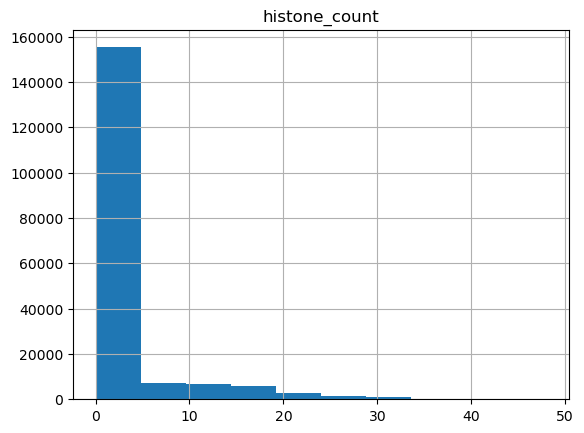

In [18]:
ax = hg19ncbiRefSeq_chr1_df.hist(column=["histone_count"])

In [19]:
hg19ncbiRefSeq_chr1_df.groupby(['histone_count'])['histone_count'].count().sort_values(ascending=False)

histone_count
0     139820
1       9034
2       3093
5       2026
4       1733
3       1650
13      1620
6       1530
15      1486
10      1359
11      1357
14      1343
16      1175
9       1172
8       1163
7       1148
18      1127
12      1059
19       994
17       917
20       889
21       783
23       535
31       426
22       413
25       401
24       302
27       212
26       172
28       157
29       152
32       112
30        66
33        42
35        41
37        21
38        20
39        16
34        11
36         9
42         5
41         3
43         3
45         3
40         2
44         2
46         2
48         2
Name: histone_count, dtype: int64

In [20]:
hg19ncbiRefSeq_chr1_df.groupby(['histone_count'])['histone_count'].count().to_csv("dataset/results/hc_group.csv")

# TO DO

Counting for all chromosomes

In [21]:
# # Counting for all chromosome
# hg19ncbiRefSeq_df.loc[:, "histone_count"] = hg19ncbiRefSeq_df.apply(\
#                             lambda row: eu.count_histone(histone_df, row), axis=1)

In [22]:
# hg19ncbiRefSeq_chr1_df.head()

In [23]:
# hg19ncbiRefSeq_df.to_csv("dataset/results/hg19ncbiRefSeq_df_histone_count.csv", index=False)

In [24]:
# hg19ncbiRefSeq_df.groupby(['histone_count'])['histone_count'].count().to_csv("dataset/results/hg19ncbiRefSeq_hc_group.csv")